# Bayesian Sharpe Ratio and Performance Comparison

This notebook illustrates how to define the Sharpe ratio as a probability model and compare the resulting posterior distributions for different return series. The Bayesian estimation for two groups provides complete distributions of credible values for the effect size, group means and their difference, standard deviations and their difference, and the normality of the data. 

Key use cases include the analysis of differences between alternative strategies, or between a strategy’s in-sample return relative to its out-of-sample return (see the notebook bayesian_sharpe_ratio for details). The Bayesian Sharpe ratio is also part of pyfolio’s Bayesian tearsheet.

## Imports & Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web

import pymc as pm
import arviz as az
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import gridspec

In [3]:
benchmark = web.DataReader('SP500', data_source='fred', start=2010)
benchmark.columns = ['benchmark']

In [4]:
with pd.HDFStore('../data/assets.h5') as store:
    stock = store['quandl/wiki/prices'].adj_close.unstack()['AMZN'].to_frame('stock')

In [5]:
data = stock.join(benchmark).pct_change().dropna().loc['2010':]

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 712 entries, 2015-06-01 to 2018-03-27
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   stock      712 non-null    float64
 1   benchmark  712 non-null    float64
dtypes: float64(2)
memory usage: 16.7 KB


## Modeling the Sharpe Ratio

To model the Sharpe ratio as a probabilistic model, we need to priors about the distribution of returns and the parameters that govern this distribution. The student t distribution exhibits fat tails relative to the normal distribution for low degrees of freedom (df) and is a reasonable choice to capture this aspect of returns. 

### Define Probability Model

Hence, we need to model the three parameters of this distribution, namely the mean and standard deviation of returns, and the degrees of freedom. We’ll assume normal and uniform distributions for the mean and the standard deviation, respectively, and an exponential distribution for the df with a sufficiently low expected value to ensure fat tails. Returns are based on these probabilistic inputs, and the annualized Sharpe ratio results from the standard computation, ignoring a risk-free rate (using daily returns).

In [7]:
mean_prior = data.stock.mean()
std_prior = data.stock.std()
std_low = std_prior / 1000
std_high = std_prior * 1000

with pm.Model() as sharpe_model:
    mean = pm.Normal('mean', mu=mean_prior, sigma=std_prior)
    std = pm.Uniform('std', lower=std_low, upper=std_high)

    nu = pm.Exponential('nu_minus_two', lam = 1 / 29, initval=4) + 2.
    returns = pm.StudentT('returns', nu=nu, mu=mean, sigma=std, observed=data.stock)

    sharpe = mean / std * np.sqrt(252)
    pm.Deterministic('sharpe', sharpe)

In [8]:
sharpe_model

        mean ~ Normal(0.0019, 0.0171)
         std ~ Uniform(1.71e-05, 17.1)
nu_minus_two ~ Exponential(f())
      sharpe ~ Deterministic(f(std, mean))
     returns ~ StudentT(f(nu_minus_two), mean, std)

### Visualize Model

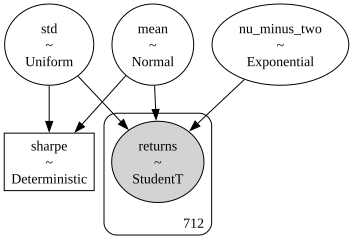

In [9]:
pm.model_to_graphviz(model=sharpe_model)

In [10]:
# optionally: persist graph
# graph = pm.model_to_graphviz(model=sharpe_model)
# graph.save('sharpe.dot')

### Approximate Inference: Hamiltonian Monte Carlo with the No U-Turn Sampler

In [ ]:
tune = 2000
draws = 200
with sharpe_model:
    trace = pm.sample(tune=tune, 
                      draws=draws, 
                      chains=4, 
                      cores=1)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [mean, std, nu_minus_two]


Sampling 4 chains for 2_000 tune and 200 draw iterations (8_000 + 800 draws total) took 4 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


### Inspect Trace

In [11]:
trace_df = az.extract(trace).to_dataframe()
trace_df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 800 entries, (0, 0) to (3, 199)
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mean          800 non-null    float64
 1   std           800 non-null    float64
 2   nu_minus_two  800 non-null    float64
 3   sharpe        800 non-null    float64
 4   chain         800 non-null    int32  
 5   draw          800 non-null    int32  
dtypes: float64(4), int32(2)
memory usage: 40.7 KB


In [12]:
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)

%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")

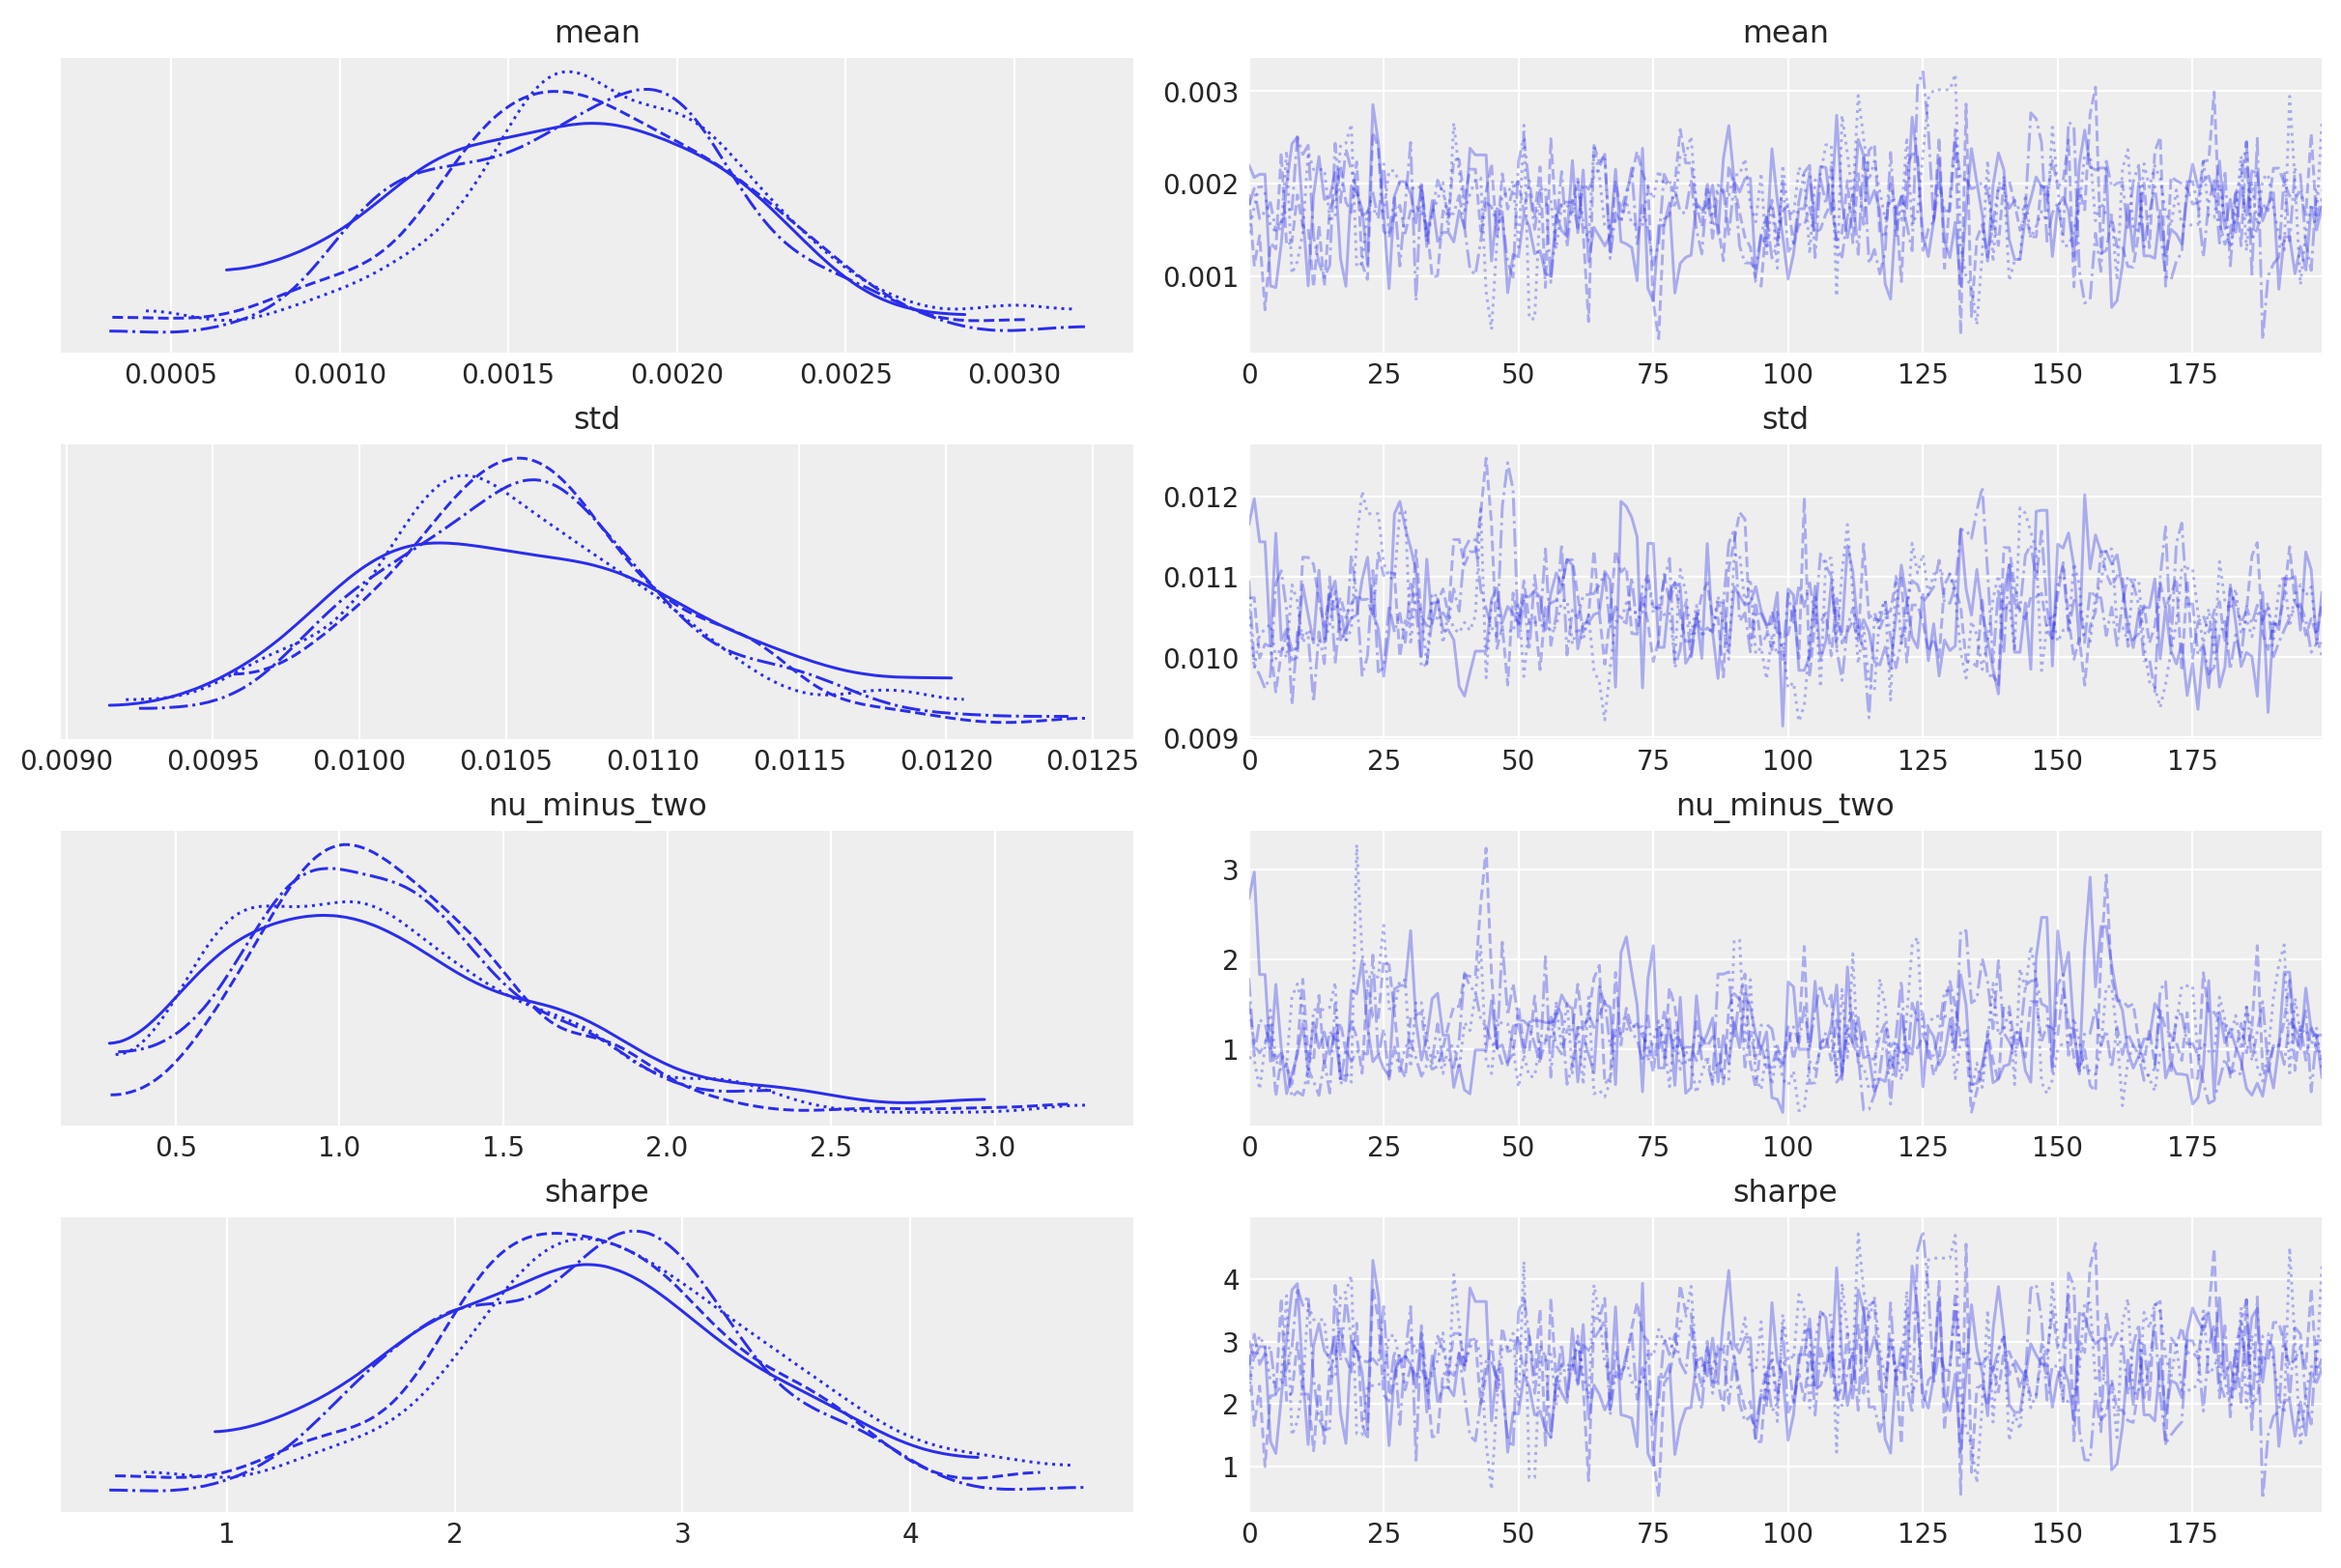

In [13]:
az.plot_trace(data=trace);

In [16]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

### Continue Sampling

In [18]:
draws = 25000
with sharpe_model:
    trace = pm.sample(draws=draws,  
                      chains=4, 
                      cores=1)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [mean, std, nu_minus_two]


Sampling 4 chains for 1_000 tune and 25_000 draw iterations (4_000 + 100_000 draws total) took 39 seconds.


In [15]:
pm.trace_to_dataframe(trace).shape

(100800, 4)

In [19]:
trace_df = az.extract(trace).to_dataframe()
trace_df.info()        

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 100000 entries, (0, 0) to (3, 24999)
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   mean          100000 non-null  float64
 1   std           100000 non-null  float64
 2   nu_minus_two  100000 non-null  float64
 3   sharpe        100000 non-null  float64
 4   chain         100000 non-null  int32  
 5   draw          100000 non-null  int32  
dtypes: float64(4), int32(2)
memory usage: 4.6 MB


In [21]:
trace_df

mean       std  nu_minus_two    sharpe  chain   draw
chain draw                                                           
0     0      0.000989  0.011335      1.371688  1.384467      0      0
      1      0.001704  0.011065      1.731528  2.445014      0      1
      2      0.002268  0.010665      0.822316  3.376467      0      2
      3      0.002112  0.010901      1.496076  3.076043      0      3
      4      0.002128  0.010476      1.541891  3.224555      0      4
...               ...       ...           ...       ...    ...    ...
3     24995  0.001782  0.010708      1.486605  2.642185      3  24995
      24996  0.001215  0.010030      0.797070  1.922720      3  24996
      24997  0.002255  0.010936      1.492322  3.273876      3  24997
      24998  0.001272  0.009680      0.627669  2.086686      3  24998
      24999  0.001221  0.010827      0.836387  1.789674      3  24999

[100000 rows x 6 columns]

In [22]:
trace_df_long = pd.melt(trace_df, id_vars=['chain', 'draw'])
trace_df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   chain     400000 non-null  int32  
 1   draw      400000 non-null  int32  
 2   variable  400000 non-null  object 
 3   value     400000 non-null  float64
dtypes: float64(1), int32(2), object(1)
memory usage: 9.2+ MB


In [23]:
trace_df_long

,chain,draw,variable,value
0,0,0,mean,0.000989
1,0,1,mean,0.001704
2,0,2,mean,0.002268
3,0,3,mean,0.002112
4,0,4,mean,0.002128
...,...,...,...,...
399995,3,24995,sharpe,2.642185
399996,3,24996,sharpe,1.922720
399997,3,24997,sharpe,3.273876
399998,3,24998,sharpe,2.086686


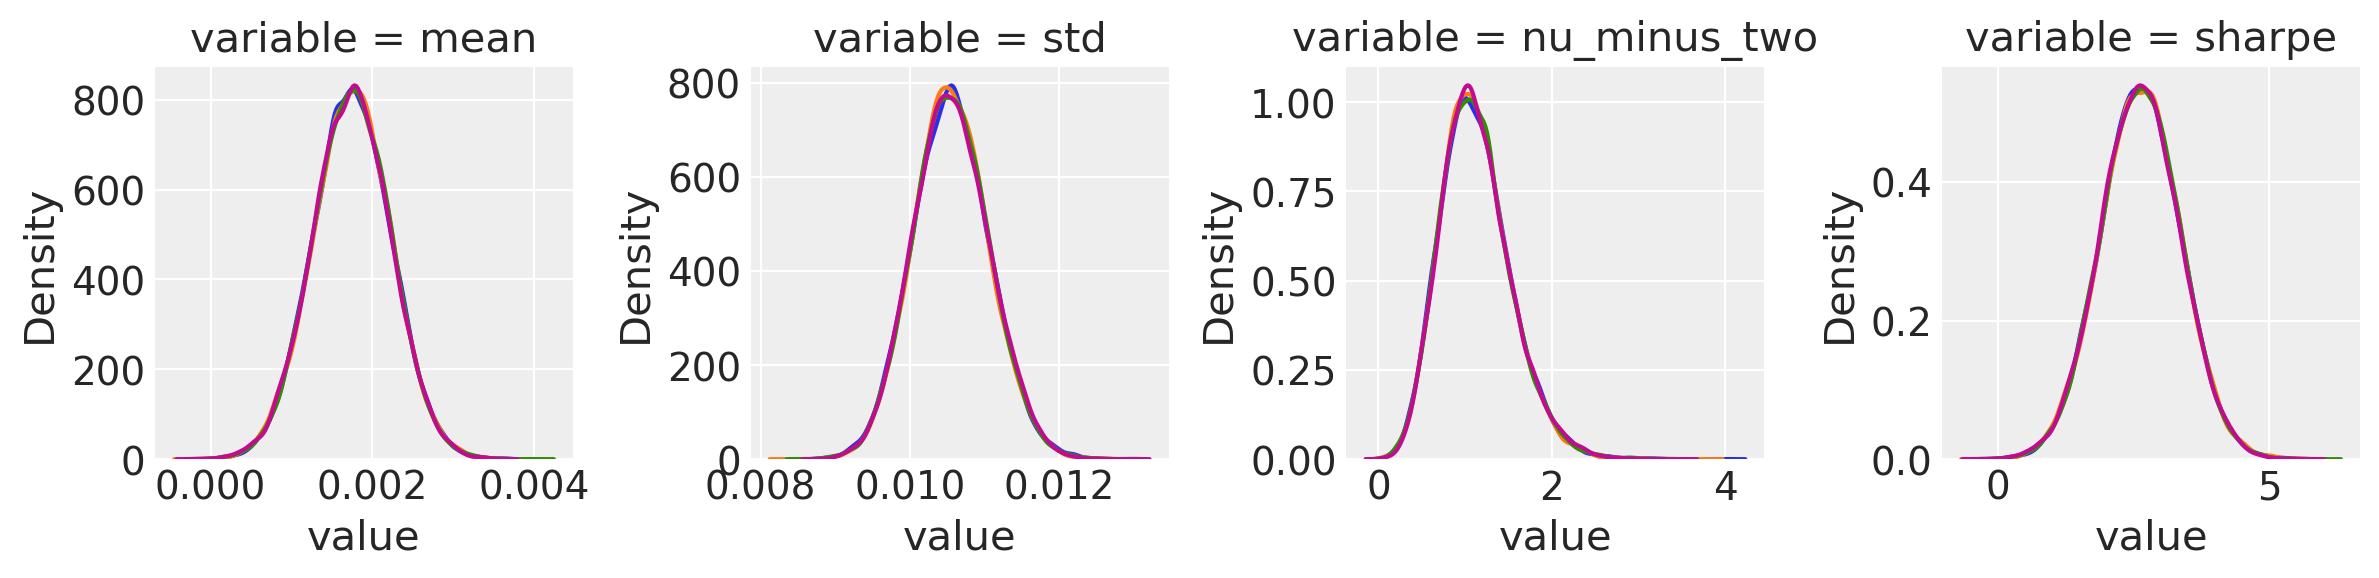

In [27]:
g = sns.FacetGrid(trace_df_long, col='variable', hue='chain', sharex='col', sharey=False)
g = g.map(sns.kdeplot, 'value')

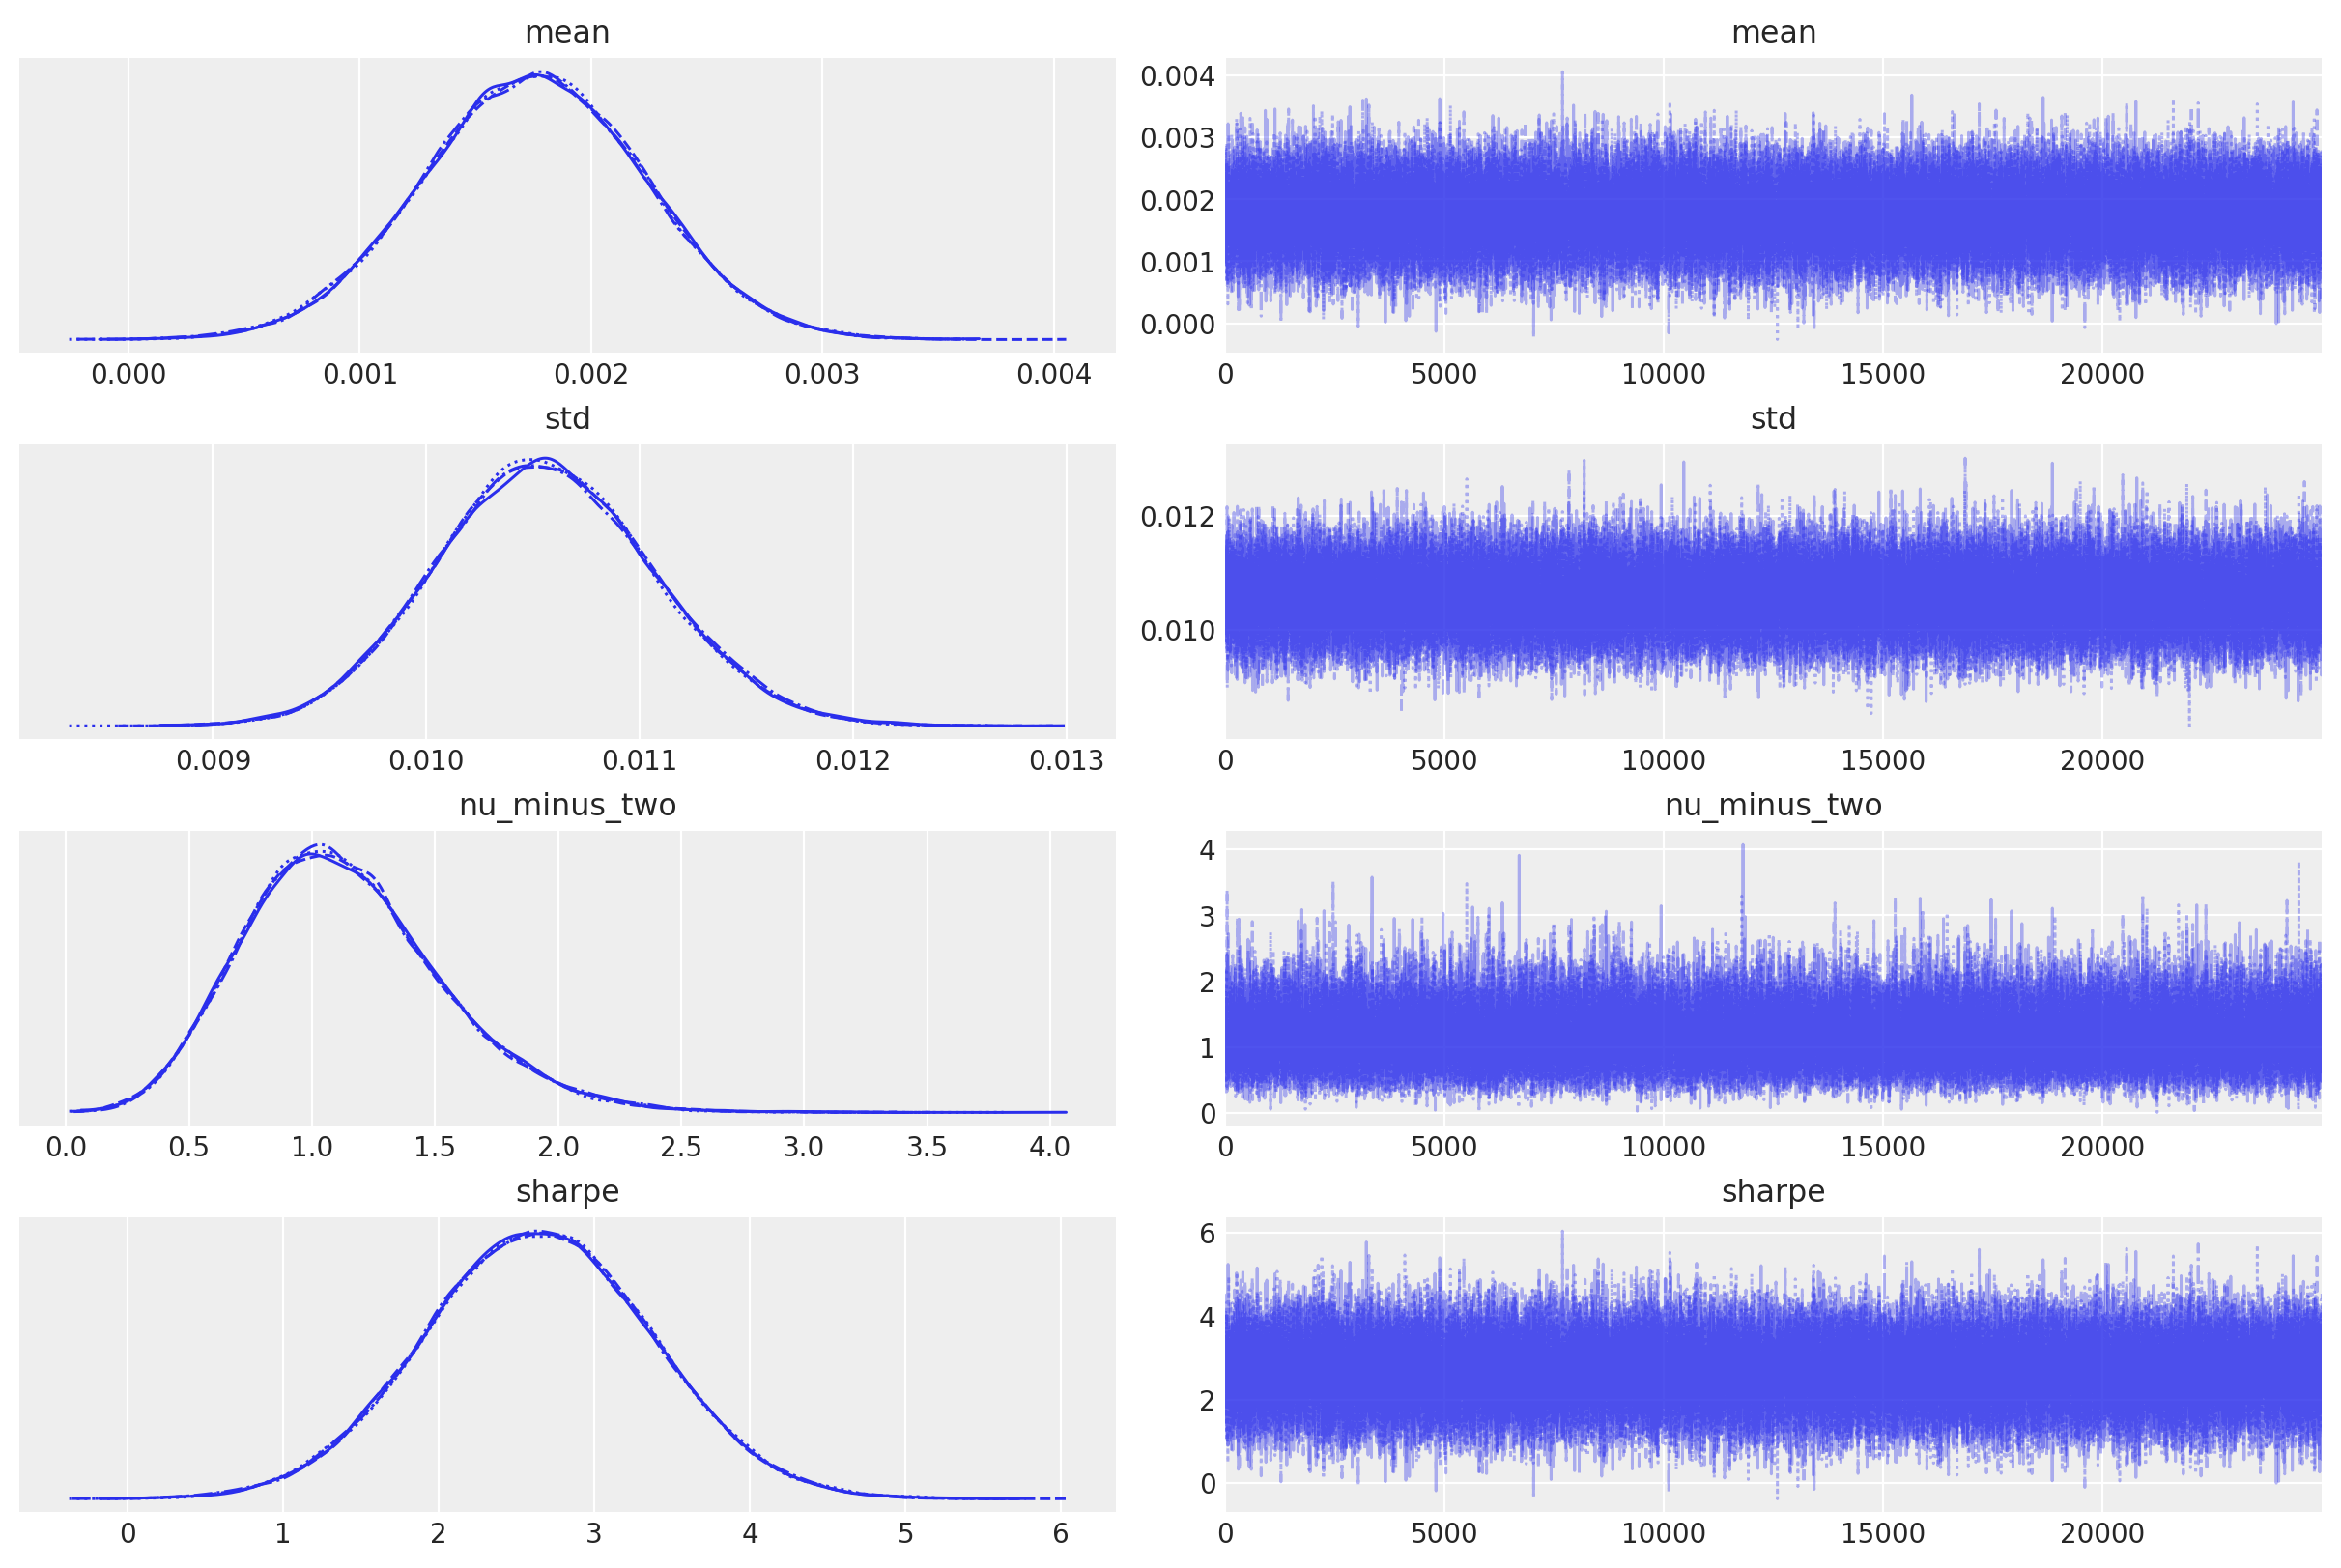

In [28]:
az.plot_trace(data=trace);

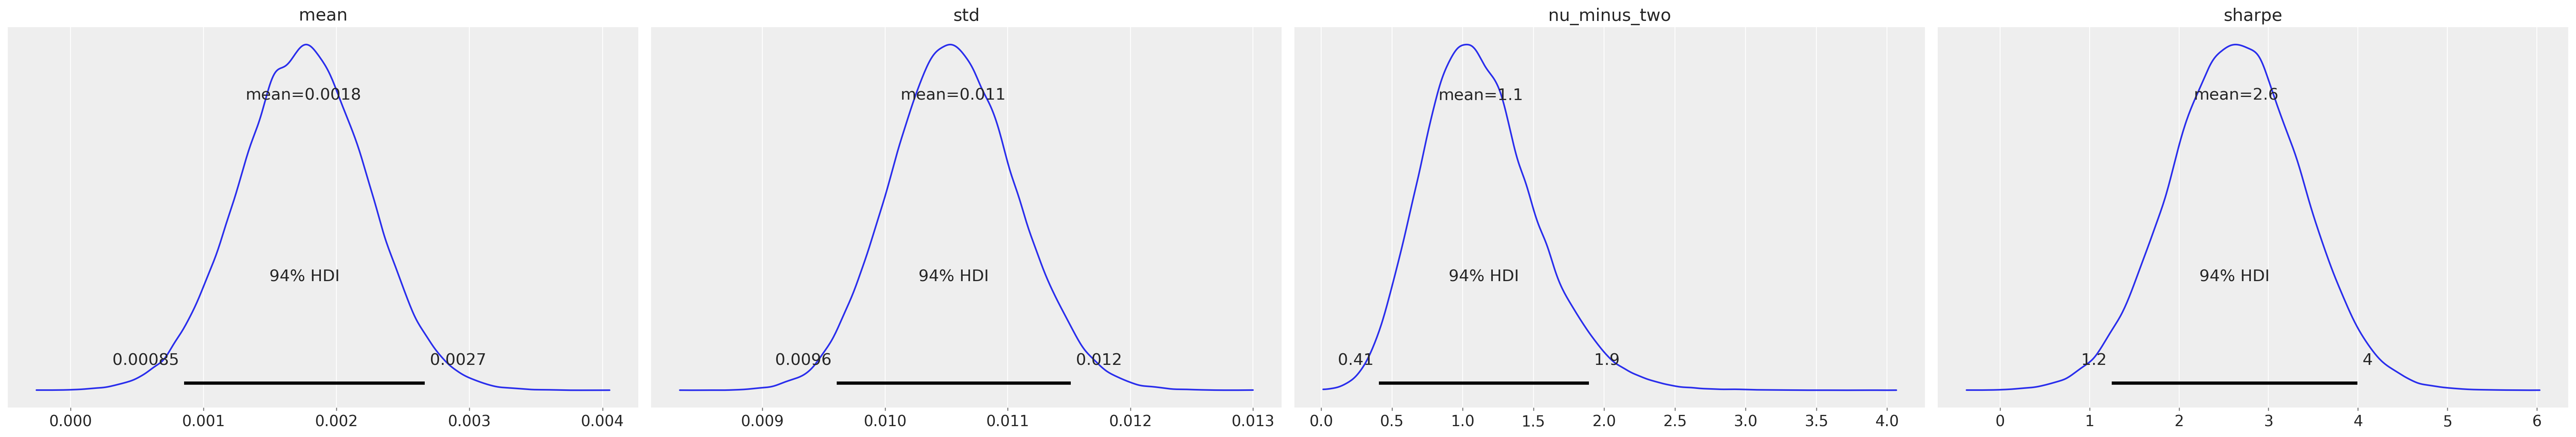

In [29]:
az.plot_posterior(data=trace);

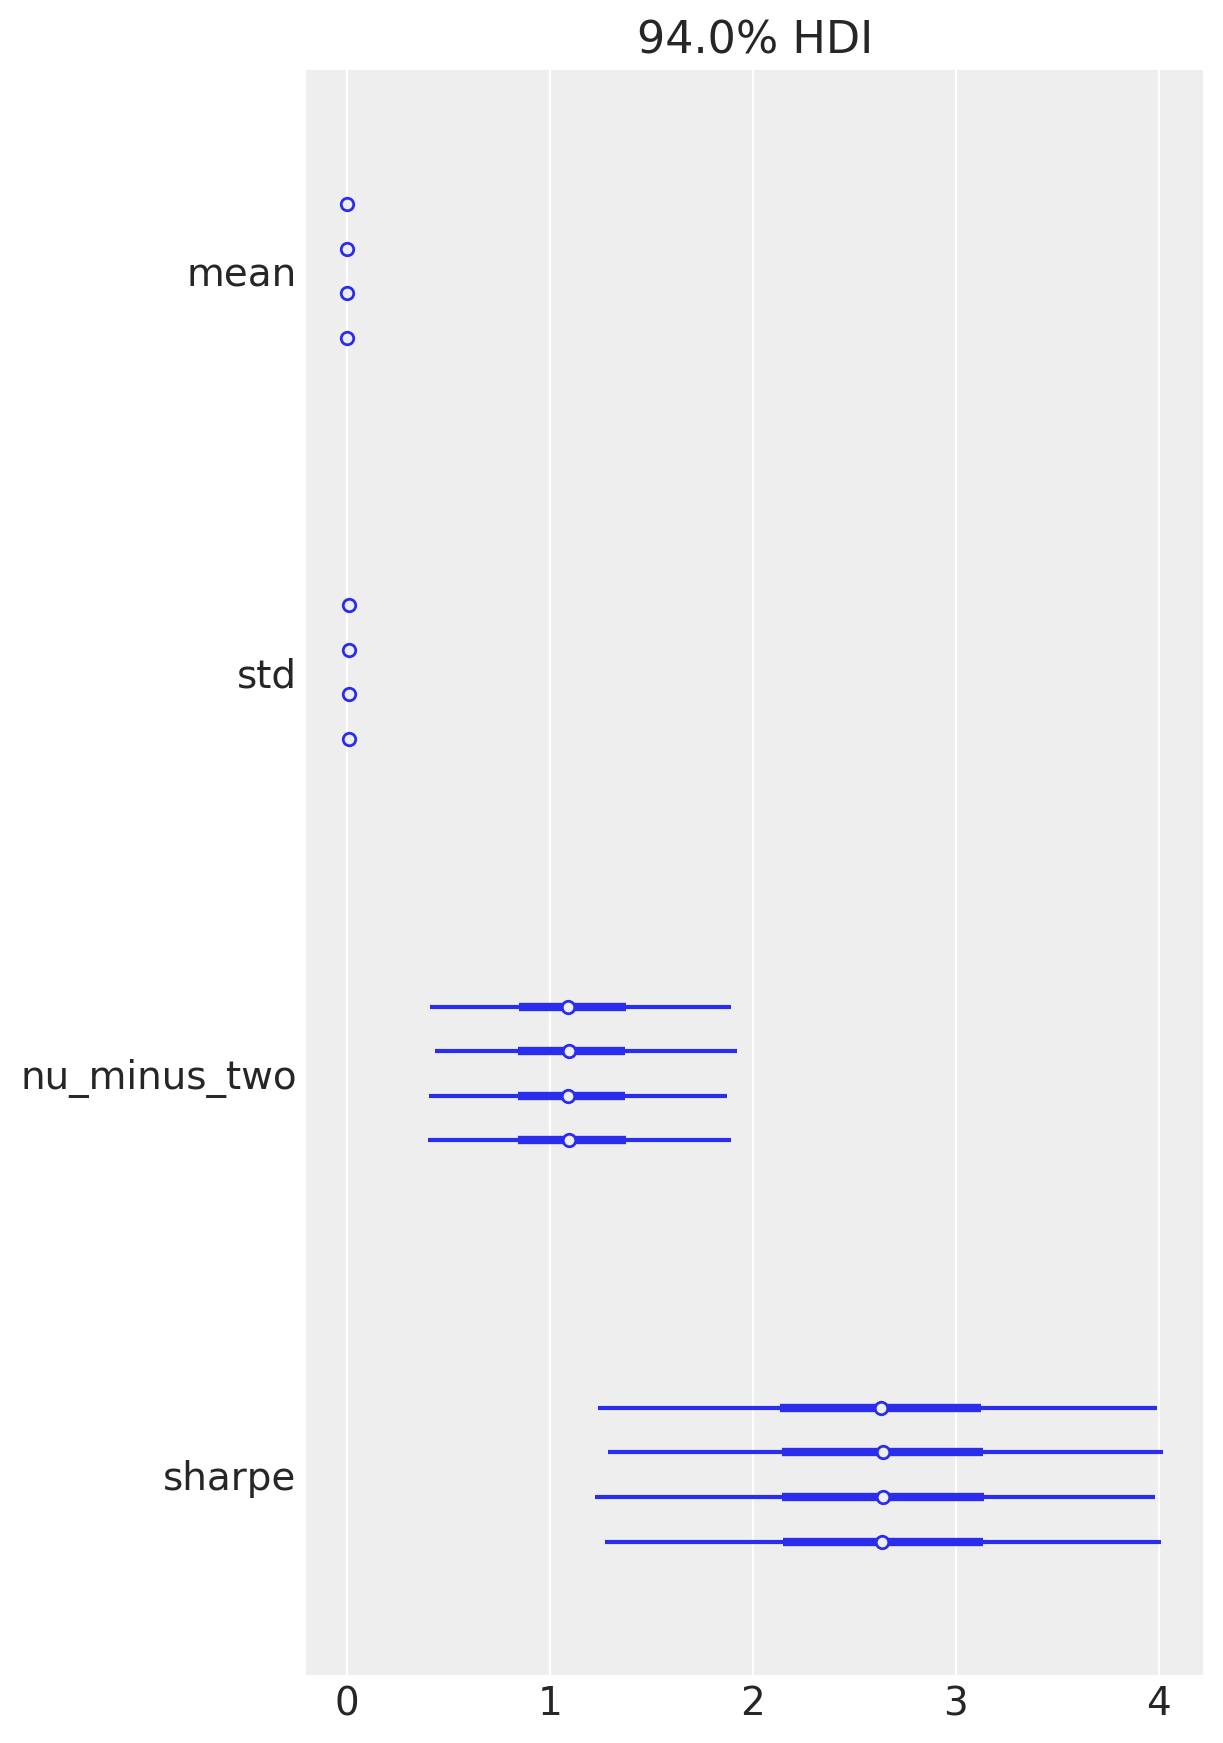

In [30]:
az.plot_forest(data=trace);

## Comparing Group Means: Bayesian Estimation Supersedes the T-Test (BEST)

This model runs a Bayesian hypothesis test to compare two return distributions. The returns could be for two different assets, or the in-sampls and out-of-sample returns for a target strategy. Returns are assumed to be T-distributed.

In addition, it computes the annualize volatility and Sharpe ratios for both return series.

The model is based on [Bayesian estimation supersedes the t-test](http://www.indiana.edu/~kruschke/BEST/BEST.pdf), John Kruschke, Journal of Experimental Psychology, 2012.

It is included in pyfolio's Bayesian tearsheet.

### The Data

In [31]:
data.describe()

,stock,benchmark
count,712.000000,712.000000
mean,0.001901,0.000336
std,0.017147,0.008256
min,-0.076100,-0.040979
25%,-0.005808,-0.002482
50%,0.001450,0.000347
75%,0.009964,0.004218
max,0.132164,0.039034


### Sharpe Ratio Comparison as a Probabilistic Model

In [32]:
group = {1: data.stock, 2: data.benchmark}
combined = pd.concat([g for i, g in group.items()])

# priors
mean_prior = combined.mean()
std_prior = combined.std()
std_low = std_prior / 1000
std_high = std_prior * 1000
T = 251 ** .5
mean, std, returns = {}, {}, {}
with pm.Model() as best:
    nu = pm.Exponential('nu_minus_two', 1 / 29, initval=4) + 2.
    for i in [1, 2]:
        mean[i] = pm.Normal(f'mean_g{i}', mu=mean_prior, sigma=std_prior, initval=group[i].mean())
        std[i] = pm.Uniform(f'std_g{i}', lower=std_low, upper=std_high, initval=group[i].std())
        returns[i] = pm.StudentT(f'returns_g{i}', nu=nu, mu=mean[i], sigma=std[i], observed=group[i])
        pm.Deterministic(f'vol_g{i}', std[i] * T)
        pm.Deterministic(f'sharpe_g{i}', mean[i] / std[i] * T)
        
    mean_diff = pm.Deterministic('mean diff', mean[1] - mean[2])
    pm.Deterministic('std diff', std[1] - std[2])
    pm.Deterministic('effect size', mean_diff / (std[i] ** 2 + std[2] ** 2) ** .5 / 2)

#### Inspecting the Model

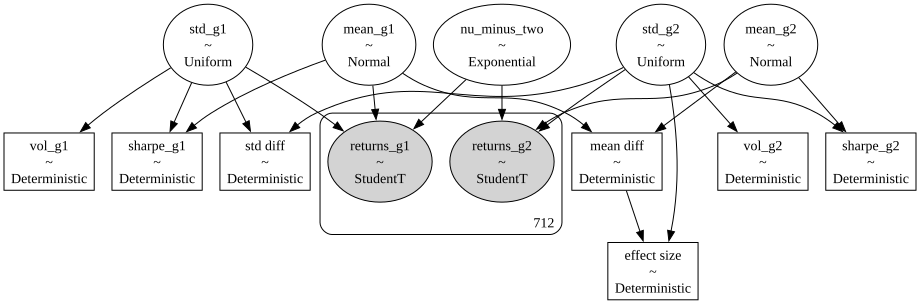

In [33]:
pm.model_to_graphviz(model=best)

In [25]:
# optional
# graph = pm.model_to_graphviz(model=best)
# graph.save('best.dot')

### HMC NUTS Sampling

In [35]:
with best:    
    trace = pm.sample(draws=10000, 
                      tune=2500, 
                      progressbar=True, 
                      chains=4,
                      cores=1)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [nu_minus_two, mean_g1, std_g1, mean_g2, std_g2]


Sampling 4 chains for 2_500 tune and 10_000 draw iterations (10_000 + 40_000 draws total) took 35 seconds.


In [36]:
az.extract(trace).to_dataframe().info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 40000 entries, (0, 0) to (3, 9999)
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mean_g1       40000 non-null  float64
 1   mean_g2       40000 non-null  float64
 2   nu_minus_two  40000 non-null  float64
 3   std_g1        40000 non-null  float64
 4   std_g2        40000 non-null  float64
 5   vol_g1        40000 non-null  float64
 6   sharpe_g1     40000 non-null  float64
 7   vol_g2        40000 non-null  float64
 8   sharpe_g2     40000 non-null  float64
 9   mean diff     40000 non-null  float64
 10  std diff      40000 non-null  float64
 11  effect size   40000 non-null  float64
 12  chain         40000 non-null  int32  
 13  draw          40000 non-null  int32  
dtypes: float64(12), int32(2)
memory usage: 4.3 MB


### Evaluating the Trace

To compare the performance of two return series, we model each group’s Sharpe ratio separately and compute the effect size as the difference between the volatility-adjusted returns. Visualizing the traces reveals granular performance insights into the distributions of each metric as illustrated by the following chart.

In [42]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

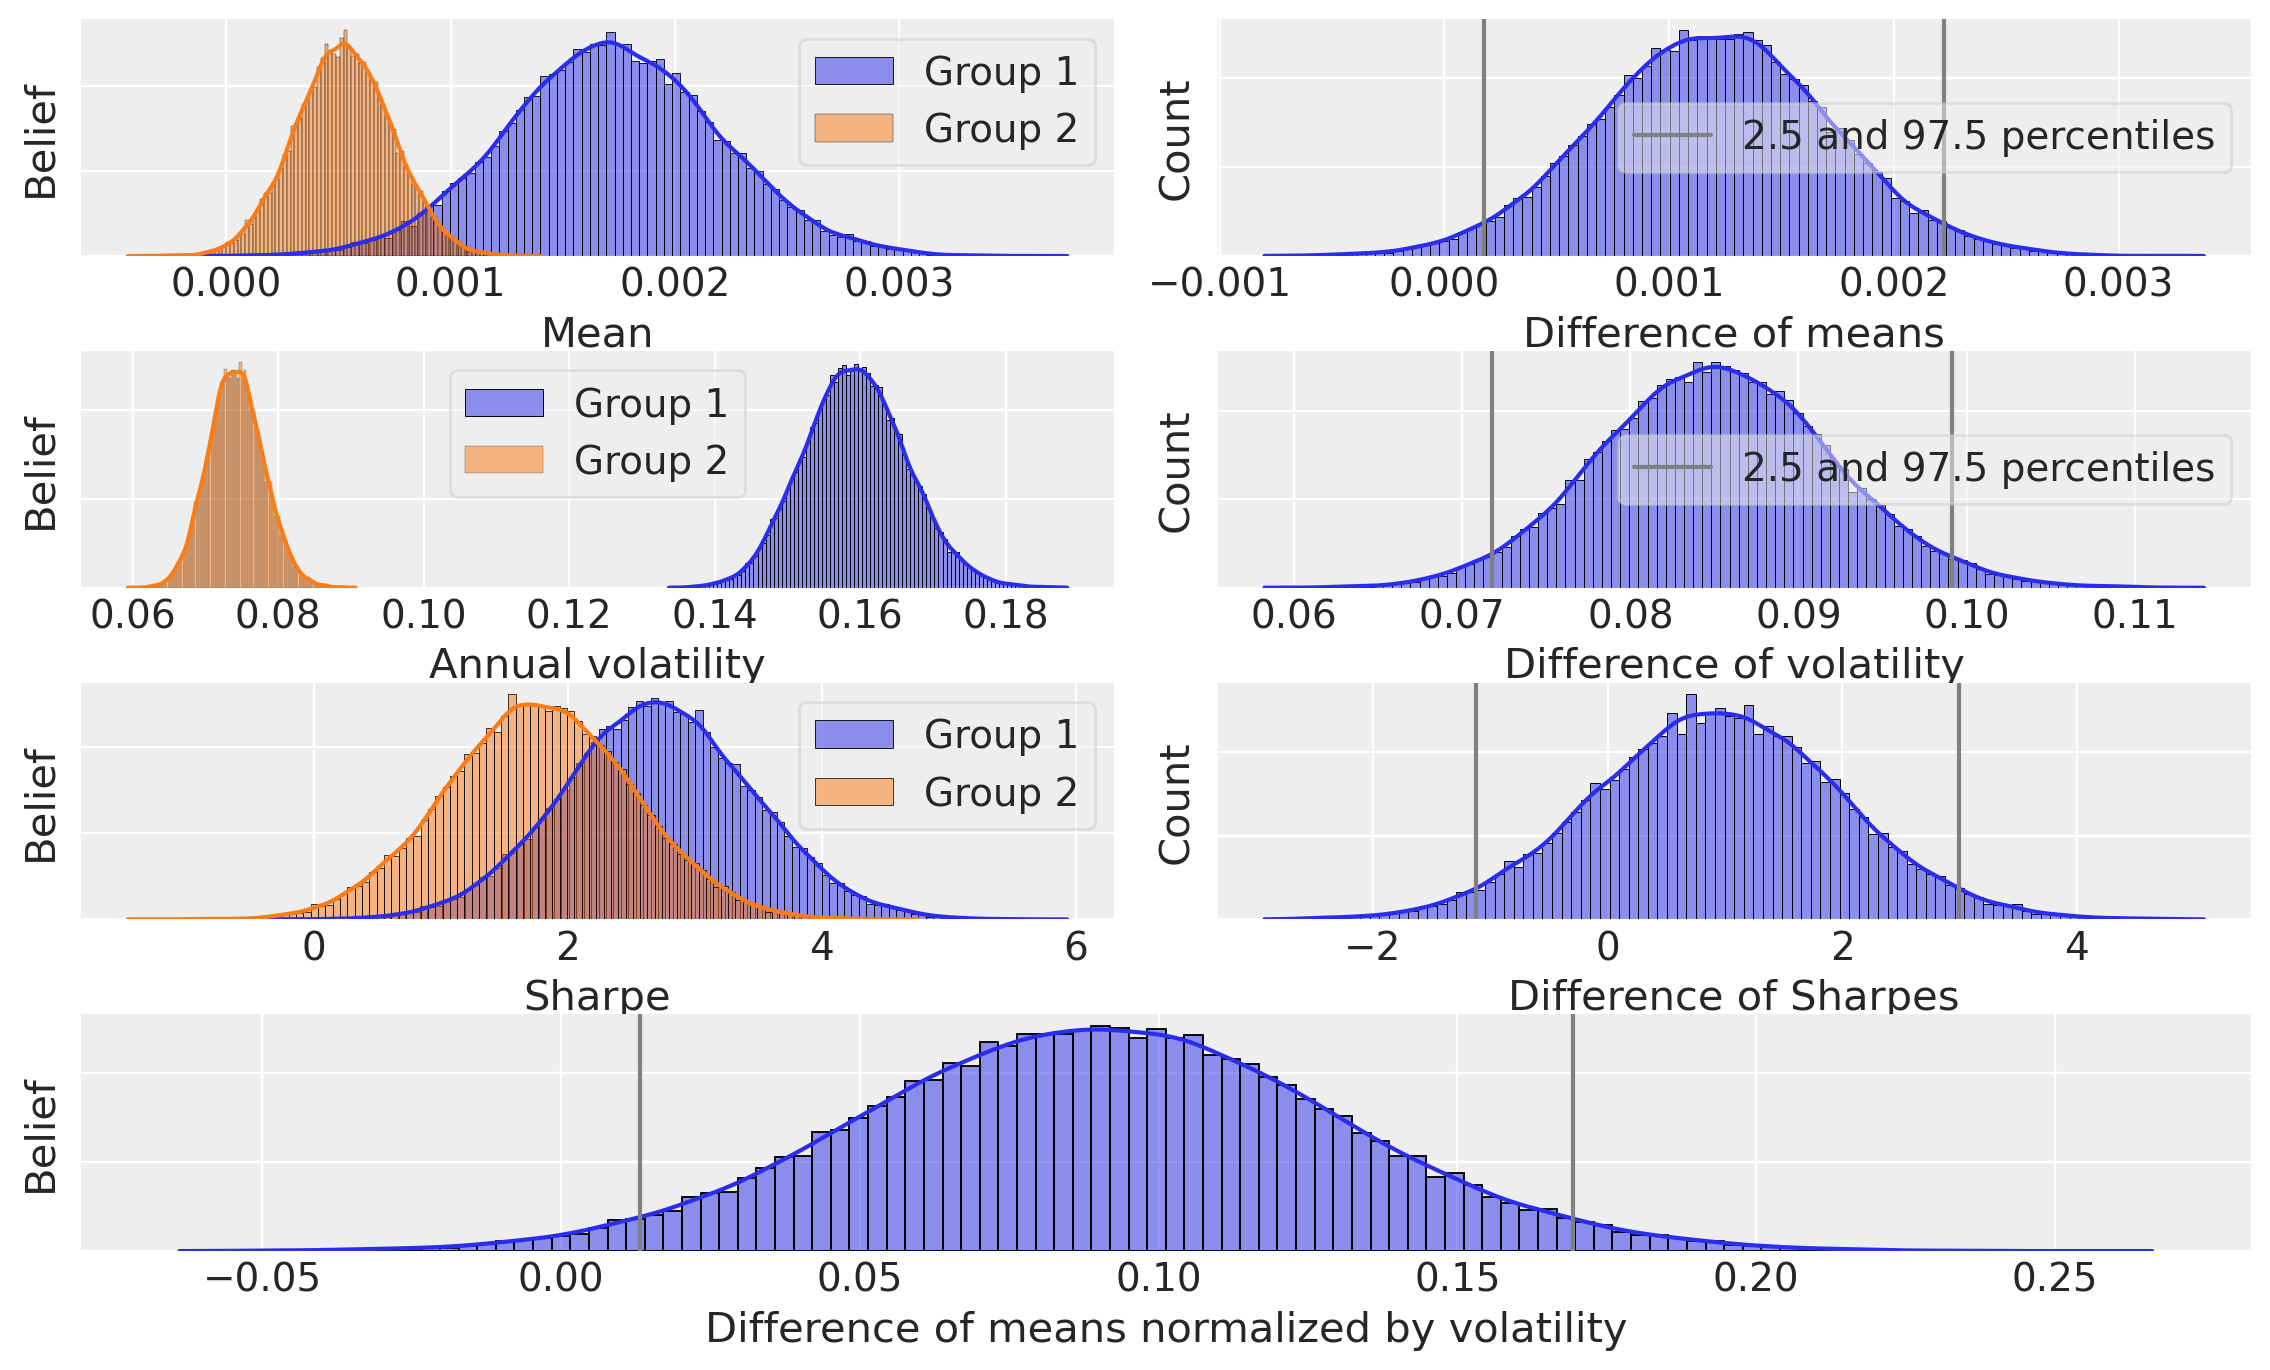

In [43]:
burn = 0
trace = trace.sel(draw=slice(burn, None))

fig = plt.figure(figsize=(14, 8), constrained_layout=True)
gs = gridspec.GridSpec(4, 2, wspace=0.1, hspace=0.4)
axs = [plt.subplot(gs[i, j]) for i in [0, 1, 2] for j in [0, 1]]
axs.append(plt.subplot(gs[3, :]))

def distplot_w_perc(data, ax):
    sns.histplot(data, kde=True, ax=ax)
    ax.axvline(stats.scoreatpercentile(data, 2.5), color='0.5', label='2.5 and 97.5 percentiles')
    ax.axvline(stats.scoreatpercentile(data, 97.5), color='0.5')

for i in [1, 2]:
    label = f'Group {i}'
    sns.histplot(trace.posterior[f'mean_g{i}'].values.flatten(), ax=axs[0], label=label, kde=True)
    sns.histplot(trace.posterior[f'vol_g{i}'].values.flatten(), ax=axs[2], label=label, kde=True)
    sns.histplot(trace.posterior[f'sharpe_g{i}'].values.flatten(), ax=axs[4], label=label, kde=True)

distplot_w_perc(trace.posterior['mean diff'].values.flatten(), axs[1])
distplot_w_perc(trace.posterior['vol_g1'].values.flatten() - trace.posterior['vol_g2'].values.flatten(), axs[3])
distplot_w_perc(trace.posterior['sharpe_g1'].values.flatten() - trace.posterior['sharpe_g2'].values.flatten(), axs[5]) 

sns.histplot(trace.posterior['effect size'].values.flatten(), ax=axs[6], kde=True)
for p in [2.5, 97.5]:
    axs[6].axvline(stats.scoreatpercentile(trace.posterior['effect size'].values.flatten(), p), color='0.5')

for i in range(5):
    axs[i].legend(loc=0, frameon=True, framealpha=0.5)

axs[0].set(xlabel='Mean', ylabel='Belief', yticklabels=[])
axs[1].set(xlabel='Difference of means', yticklabels=[])
axs[2].set(xlabel='Annual volatility', ylabel='Belief', yticklabels=[])
axs[3].set(xlabel='Difference of volatility', yticklabels=[])
axs[4].set(xlabel='Sharpe', ylabel='Belief', yticklabels=[])
axs[5].set(xlabel='Difference of Sharpes', yticklabels=[])
axs[6].set(xlabel='Difference of means normalized by volatility', ylabel='Belief', yticklabels=[])
sns.despine()
fig.tight_layout()

In [48]:
def plot_traces(traces, burnin=2000):
    ''' 
    Plot traces with overlaid means and values
    '''
    # Get summary statistics using ArviZ
    summary = az.summary(traces.sel(draw=slice(burnin, None)))['mean'].to_dict()
    
    # Plot traces using ArviZ's built-in function
    ax = az.plot_trace(traces.sel(draw=slice(burnin, None)),
                      figsize=(15, len(traces.posterior.data_vars)*1.5),
                      lines=summary)

    # Add annotations for mean values
    for i, mn in enumerate(summary.values()):
        ax[i, 0].annotate(f'{mn:.2f}', 
                         xy=(mn, 0), 
                         xycoords='data', 
                         xytext=(5, 10), 
                         textcoords='offset points', 
                         rotation=90, 
                         va='bottom', 
                         fontsize='large', 
                         color='#AA0022')

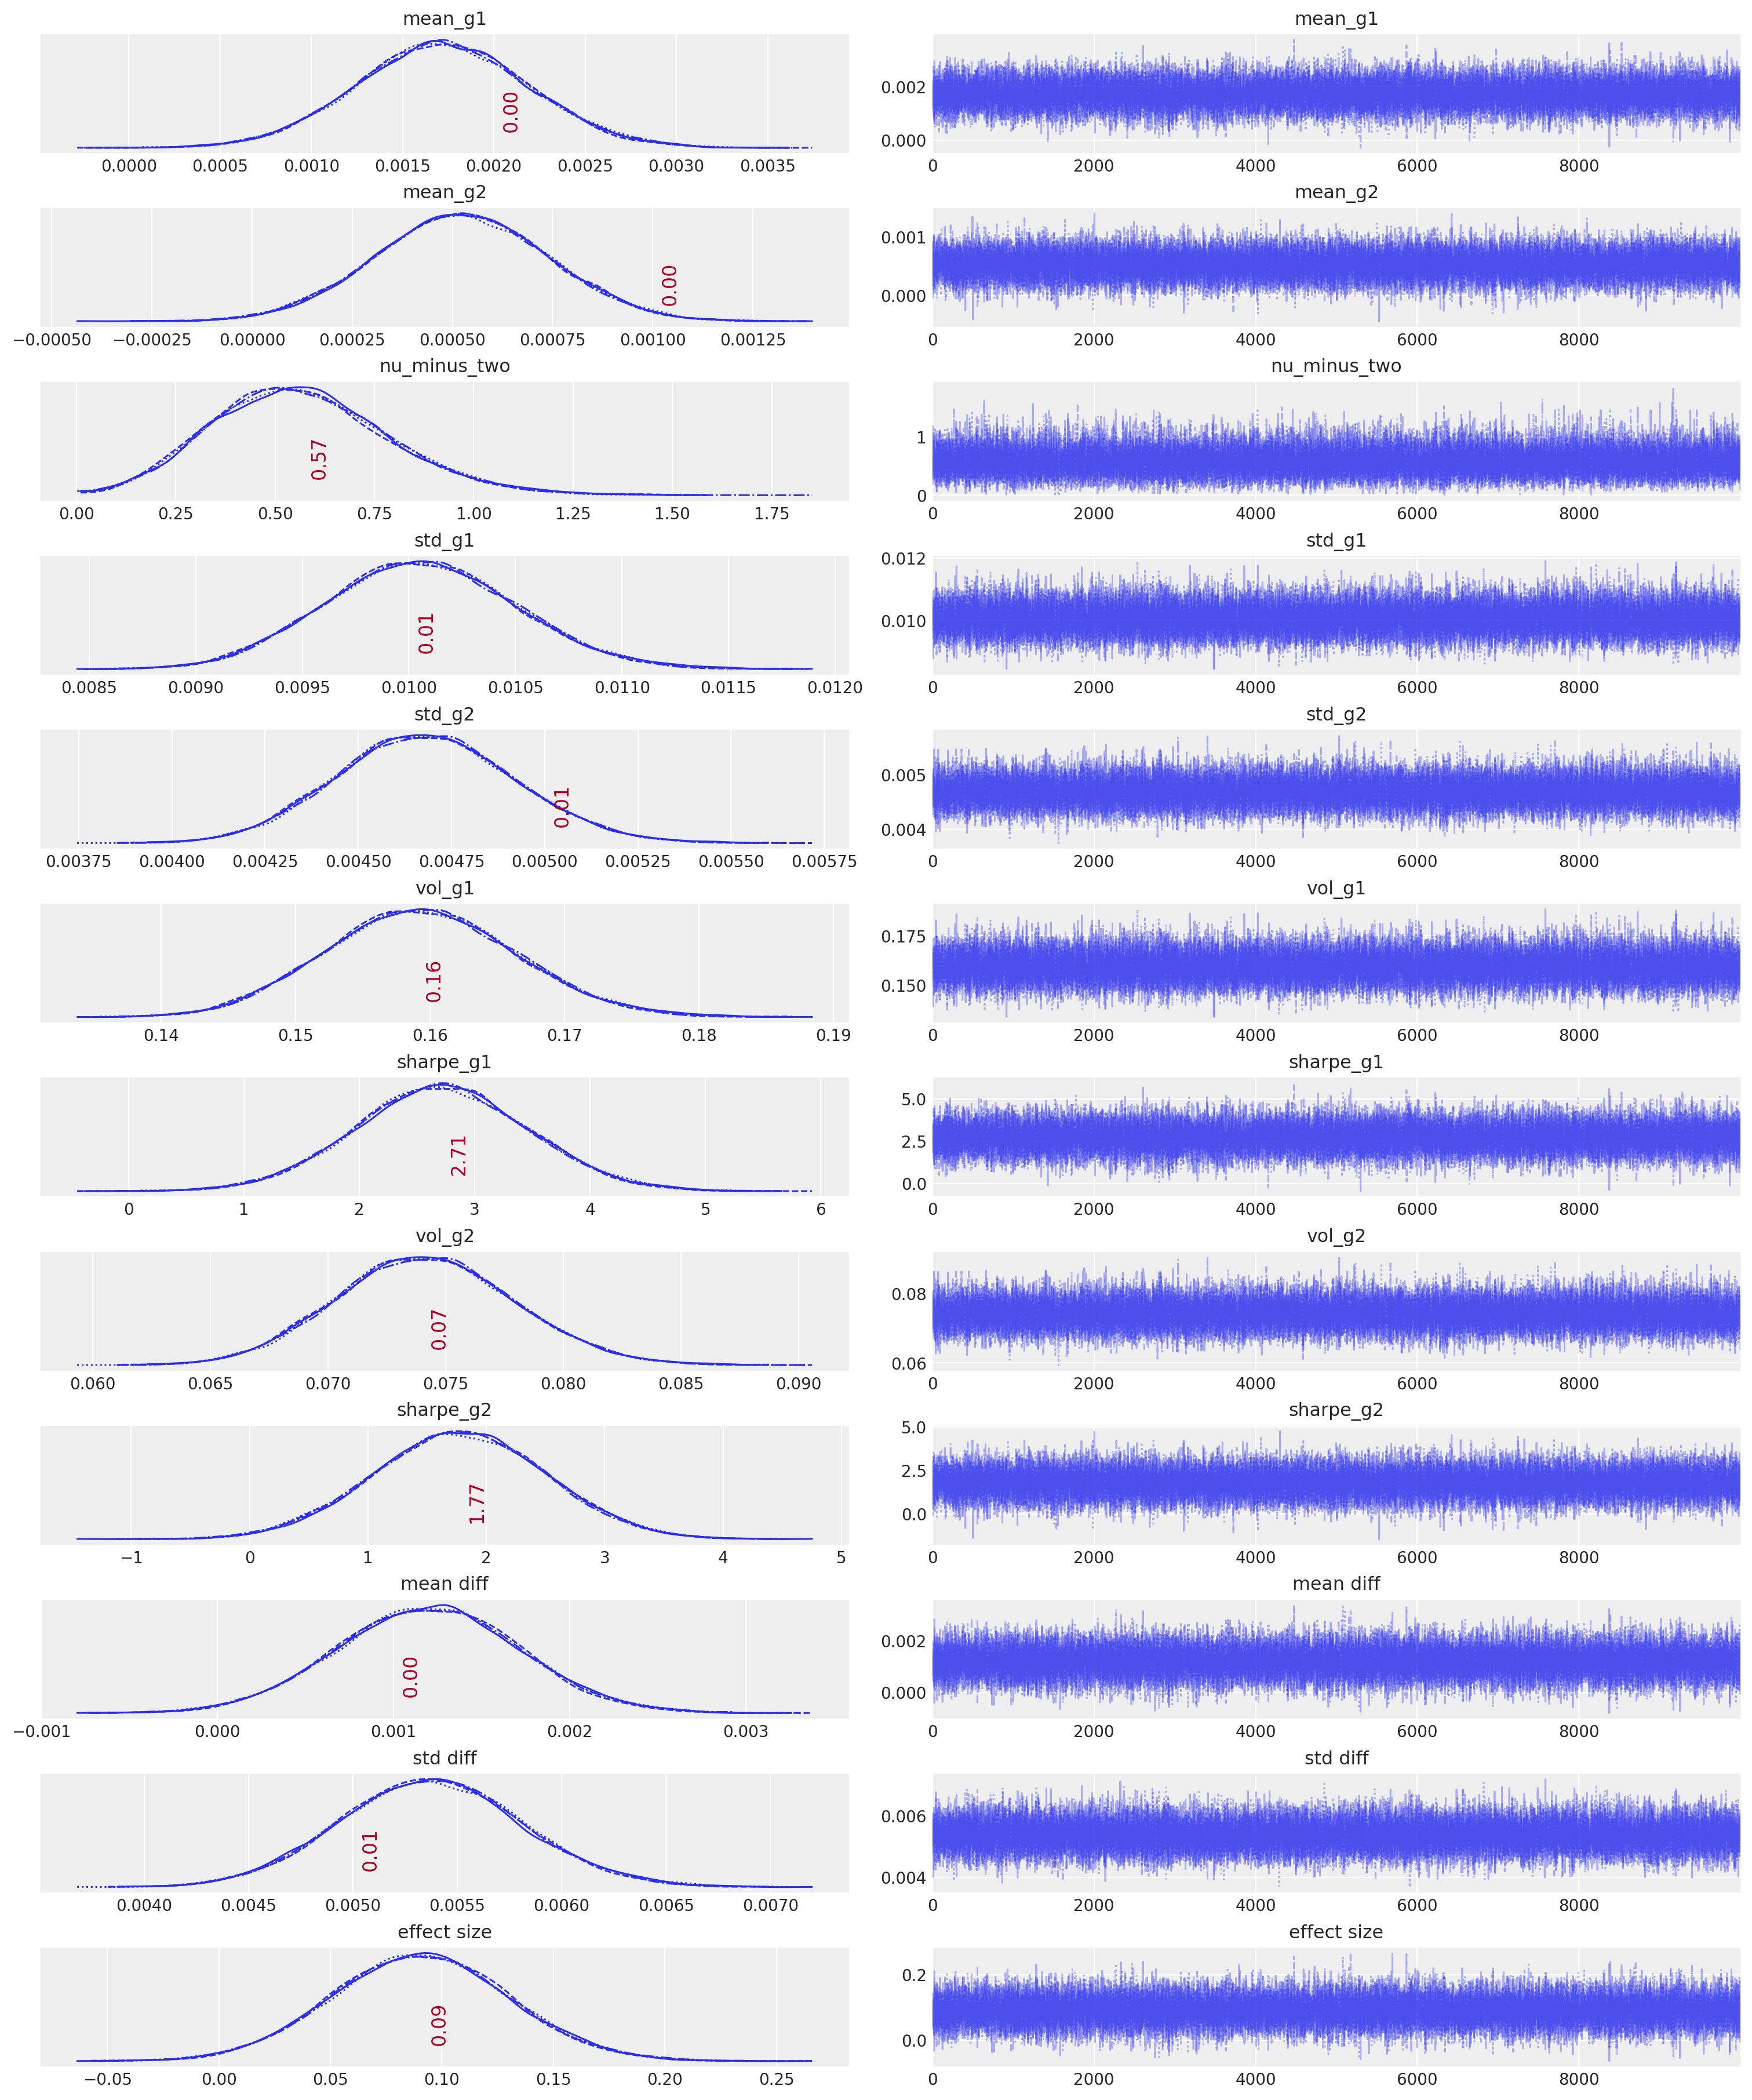

In [49]:
plot_traces(trace, burnin=0)